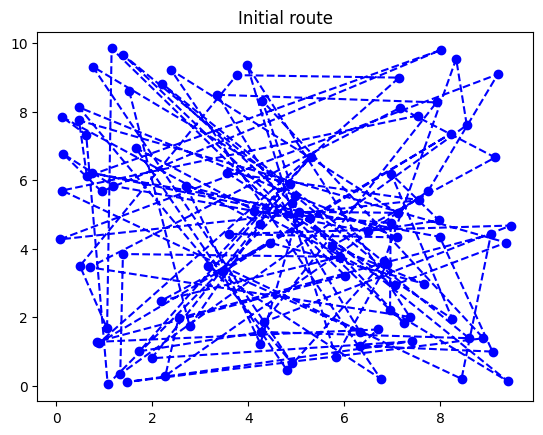

Initial route length:
703.1260041828453
Final route length:
106.76669283901079


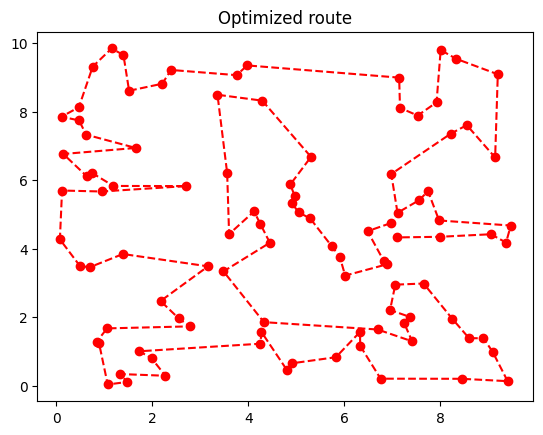

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def optimise_route(cities, initial_temperature, end_temperature):
    n_cities = cities.shape[0]

    # Setup initial cities visit order as a numbered array
    # Python array indices start from 0
    state = np.arange(n_cities)

    # Calculate the energy for the initial condition,
    # in our meaning = route length
    current_energy = calculate_energy(state, cities)

    print("Initial route length:")
    print(current_energy)

    T = initial_temperature

    # Main loop
    for k in range(1, 100001):

        # Create a new order for visiting cities
        state_candidate = generate_state_candidate(state)

        # Calculate new order energy (route length)
        candidate_energy = calculate_energy(
            state_candidate,
            cities
        )

        # If the new order has less energy
        if candidate_energy < current_energy:
            # It becomes the new order
            state = state_candidate
            current_energy = candidate_energy

        else:
            # Otherwise, calculate the probability
            # of accepting a bad solution
            p = get_transition_probability(
                candidate_energy - current_energy,
                T
            )

            # If the transition occurs with a given probability
            if is_transition(p):
                # Accept the new bad solution
                state = state_candidate
                current_energy = candidate_energy

        # Decrease temperature
        T = decrease_temperature(initial_temperature, k)

        # Second exit condition
        if T <= end_temperature:
            break

    print("Final route length:")
    print(current_energy)

    return state

def calculate_energy(sequence, cities):
    # Calculate route length
    n = len(sequence)
    E = 0

    for i in range(n - 1):
        E += metric(
            cities[sequence[i]],
            cities[sequence[i + 1]]
        )

    # Add distance between finish and start
    # to return to the initial point
    E += metric(
        cities[sequence[-1]],
        cities[sequence[0]]
    )

    return E

def metric(A, B):
    # Calculate distance between 2 points
    distance = (A - B) ** 2
    distance = np.sqrt(distance)
    distance = np.sum(distance)

    return distance

def decrease_temperature(initial_temperature, k):
    T = initial_temperature * 0.1 / k
    return T

def get_transition_probability(dE, T):
    P = np.exp(-dE / T)
    return P

def is_transition(probability):
    if np.random.rand() <= probability:
        a = 1
    else:
        a = 0

    return a

def generate_state_candidate(seq):
    """
    Generate a candidate tour by performing a 2-opt move:
    """
    seq = seq.copy()
    n = len(seq)

    # Choose two distinct cut points
    a = np.random.randint(n)
    b = np.random.randint(n)
    while b == a:          # avoid cutting the same edge twice
        b = np.random.randint(n)

    # Determine the indices of the segment to reverse (from a+1 to b, wrapping)
    start_seg = (a + 1) % n
    end_seg = b

    if end_seg >= start_seg:
        seg_indices = list(range(start_seg, end_seg + 1))
    else:
        seg_indices = list(range(start_seg, n)) + list(range(0, end_seg + 1))

    # Reverse the segment in place
    seq[seg_indices] = seq[seg_indices][::-1]
    return seq

n_cities = 100
initial_temperature = 100
end_temperature = 0

# Setup initial cities positions as a 2-dimensional array (x, y)
# with a maximum coordinate value of 10
cities = np.random.rand(n_cities, 2) * 10

# Create new canvas for plot
plt.figure()

# Draw initial route
# cities[:, 0] - the colon ':' specifies all elements in that dimension
plt.plot(cities[:, 0], cities[:, 1], "b--o")
plt.title("Initial route")
plt.show()
# Call our optimization function
state = optimise_route(
    cities,
    initial_temperature,
    end_temperature
)
plt.figure()

# Draw final route
plt.plot(cities[state, 0], cities[state, 1], "r--o")
plt.title("Optimized route")
plt.show()
